In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sys
sys.path.append("/home/z5297792/UNSW-MRes/MRes/modules") 
from utils import unit_det, fit_psi_params, psi_params, ellipse_aspect_ratio, axis_ratio_from_Q, espra

import re
def extract_number(s):
    match = re.search(r'\d+', s)
    return int(match.group()) if match else None


In [2]:
# def doppio(x1, y1, u1, v1, x2, y2, u2, v2, degree=3, plot=False):
#     def nan_return():
#         nan2 = np.full((2, 2), np.nan)
#         return np.nan, np.nan, np.nan, nan2, np.nan

#     def clean(*arrs):
#         arrs = [np.asarray(a, dtype=float).ravel() for a in arrs]
#         mask = np.logical_and.reduce([np.isfinite(a) for a in arrs])
#         return [a[mask] for a in arrs]

#     def find_root(x, y, degree=3):
#         if x.size < degree + 1:
#             return np.nan

#         try:
#             coeffs = np.polyfit(x, y, degree)
#             roots = np.roots(coeffs)
#         except Exception:
#             return np.nan

#         real_roots = roots[np.isreal(roots)].real
#         if real_roots.size == 0:
#             return np.nan

#         mid_x = np.median(x)
#         return real_roots[np.argmin(np.abs(real_roots - mid_x))]

#     def tangent_at_root(x, y, root_x, degree=3):
#         if x.size < degree + 1 or not np.isfinite(root_x):
#             return np.nan, np.nan, np.nan

#         try:
#             coeffs = np.polyfit(x, y, degree)
#         except Exception:
#             return np.nan, np.nan, np.nan

#         p = np.poly1d(coeffs)
#         dp = np.polyder(p)

#         slope = dp(root_x)
#         intercept = p(root_x) - slope * root_x

#         y_fit = p(x)
#         ss_tot = np.sum((y - np.mean(y))**2)
#         ss_res = np.sum((y - y_fit)**2)
#         r2 = 1.0 if np.isclose(ss_tot, 0) else 1 - ss_res / ss_tot

#         return slope, intercept, r2

#     x1, y1, u1, v1 = clean(x1, y1, u1, v1)
#     x2, y2, u2, v2 = clean(x2, y2, u2, v2)

#     if len(x1) == 0 or len(x2) == 0:
#         return nan_return()

#     pts1 = np.column_stack((x1, y1))
#     pts2 = np.column_stack((x2, y2))

#     common = np.array([p for p in pts1 if np.any(np.all(pts2 == p, axis=1))])

#     if len(common) != 1:
#         return nan_return()

#     center_x, center_y = common[0]

#     xx = x1 - center_x
#     yy = y2 - center_y

#     x0 = find_root(xx, v1, degree)
#     y0 = find_root(yy, u2, degree)

#     a1, a0, r2a = tangent_at_root(xx, u1, x0, degree)
#     b1, b0, r2b = tangent_at_root(xx, v1, x0, degree)
#     c1, c0, r2c = tangent_at_root(yy, u2, y0, degree)
#     d1, d0, r2d = tangent_at_root(yy, v2, y0, degree)

#     vals = [a1, a0, r2a, b1, b0, r2b, c1, c0, r2c, d1, d0, r2d]
#     if not np.all(np.isfinite(vals)):
#         return nan_return()

#     print(pd.DataFrame({'a':[a0, a1], 'b': [b0, b1],
#                         'c': [c0, c1], 'd': [d0, d1]}))

#     # print(f'a1: {a1} or -d1: {-d1}')
#     # a1 = a1 if r2a >= r2d else -d1

#     Omega = np.sign(b1)*np.sqrt(-b1*c1-a1**2)

#     Q = np.array([[b1, -a1], [-a1, -c1]])/Omega

#     xc = (a0*a1+c1*d0)/Omega**2
#     yc = (a0*b1-a1*d0)/Omega**2

#     w = Omega * (Q[0,0] + Q[1,1])

#     print(f'x0: {x0} or {-b0/b1}')
#     print(f'y0: {y0} or {-c0/c1}')

#     return xc + center_x, yc + center_y, w, Q, Omega
    

In [3]:
from scipy.optimize import least_squares

def doppio(x1, y1, u1, v1, x2, y2, u2, v2):
    def nan_return():
        nan2 = np.full((2, 2), np.nan)
        coeffs = pd.DataFrame(
            np.nan,
            index=['0', '1', '2', '3'],
            columns=['A', 'B', 'C', 'D']
        )
        return {
            'xc': np.nan,
            'yc': np.nan,
            'Omega': np.nan,
            'Q': nan2,
            'x0': np.nan,
            'y0': np.nan,
            'A': np.full(4, np.nan),
            'B': np.full(4, np.nan),
            'C': np.full(4, np.nan),
            'D': np.full(4, np.nan),
            'a0': np.nan, 'a1': np.nan,
            'b0': np.nan, 'b1': np.nan,
            'c0': np.nan, 'c1': np.nan,
            'd0': np.nan, 'd1': np.nan,
            'coeffs': coeffs,
            'success': False
        }

    def clean(*arrs):
        arrs = [np.asarray(a, dtype=float).ravel() for a in arrs]
        m = np.logical_and.reduce([np.isfinite(a) for a in arrs])
        return [a[m] for a in arrs]

    def poly3(p, z):
        return p[0] + p[1]*z + p[2]*z**2 + p[3]*z**3

    x1, y1, u1, v1 = clean(x1, y1, u1, v1)
    x2, y2, u2, v2 = clean(x2, y2, u2, v2)

    if len(x1) < 4 or len(y2) < 4:
        return nan_return()

    pts1 = np.column_stack((x1, y1))
    pts2 = np.column_stack((x2, y2))

    common = np.array([p for p in pts1 if np.any(np.all(pts2 == p, axis=1))])

    if len(common) != 1:
        return nan_return()

    center_x, center_y = common[0]

    # Since transects intersect at the origin, the horizontal transect uses x1
    # and the vertical transect uses y2.
    x = x1 - center_x
    y = y2 - center_y

    # Initial guesses
    x0_guess = x[np.argmin(np.abs(v1))] if len(x) else 0.0
    y0_guess = y[np.argmin(np.abs(u2))] if len(y) else 0.0

    pA = np.polyfit(x, u1, 3)[::-1]
    pB = np.polyfit(x, v1, 3)[::-1]
    pC = np.polyfit(y, u2, 3)[::-1]
    pD = np.polyfit(y, v2, 3)[::-1]

    # Free parameters:
    # x0, y0,
    # A0,A1,A2,A3,
    # B1,B2,B3,   with B0 set so V1(x0)=0 exactly
    # C1,C2,C3,   with C0 set so U2(y0)=0 exactly
    # D0,D2,D3,   with D1 set so d1=-a1 exactly
    p0 = np.array([
        x0_guess, y0_guess,
        pA[0], pA[1], pA[2], pA[3],
        pB[1], pB[2], pB[3],
        pC[1], pC[2], pC[3],
        pD[0], pD[2], pD[3]
    ], dtype=float)

    def unpack(p):
        x0, y0 = p[0], p[1]

        A0, A1, A2, A3 = p[2:6]
        B1, B2, B3 = p[6:9]
        C1, C2, C3 = p[9:12]
        D0, D2, D3 = p[12:15]

        a1 = A1 + 2*A2*x0 + 3*A3*x0**2
        b1 = B1 + 2*B2*x0 + 3*B3*x0**2
        c1 = C1 + 2*C2*y0 + 3*C3*y0**2

        B0 = -x0 * b1
        C0 = -y0 * c1
        D1 = -a1 - 2*D2*y0 - 3*D3*y0**2

        A = np.array([A0, A1, A2, A3], dtype=float)
        B = np.array([B0, B1, B2, B3], dtype=float)
        C = np.array([C0, C1, C2, C3], dtype=float)
        D = np.array([D0, D1, D2, D3], dtype=float)

        return x0, y0, A, B, C, D

    def residuals(p):
        x0, y0, A, B, C, D = unpack(p)

        U1 = poly3(A, x)
        V1 = poly3(B, x)
        U2 = poly3(C, y)
        V2 = poly3(D, y)

        return np.r_[U1 - u1, V1 - v1, U2 - u2, V2 - v2]

    res = least_squares(residuals, p0, method='trf')

    if not res.success:
        return nan_return()

    x0, y0, A, B, C, D = unpack(res.x)

    A0, A1, A2, A3 = A
    B0, B1, B2, B3 = B
    C0, C1, C2, C3 = C
    D0, D1, D2, D3 = D

    # Tangent coefficients
    a1 = A1 + 2*A2*x0 + 3*A3*x0**2
    a0 = (A0 + A1*x0 + A2*x0**2 + A3*x0**3) - x0*a1

    b1 = B1 + 2*B2*x0 + 3*B3*x0**2
    b0 = -x0*b1

    c1 = C1 + 2*C2*y0 + 3*C3*y0**2
    c0 = -y0*c1

    d1 = D1 + 2*D2*y0 + 3*D3*y0**2
    d0 = (D0 + D1*y0 + D2*y0**2 + D3*y0**3) - y0*d1

    # Enforce d1 = -a1 numerically if tiny mismatch remains
    d1 = -a1

    radicand = -b1*c1 - a1**2
    if radicand <= 0 or not np.isfinite(radicand):
        return nan_return()

    Omega = np.sign(b1) * np.sqrt(radicand)
    if Omega == 0 or not np.isfinite(Omega):
        return nan_return()

    Q = (1 / Omega) * np.array([
        [b1,  -a1],
        [-a1, -c1]
    ], dtype=float)

    xc = (a0*a1 + c1*d0) / Omega**2
    yc = (a0*b1 - a1*d0) / Omega**2

    coeffs = pd.DataFrame(
        {
            'A': A,
            'B': B,
            'C': C,
            'D': D
        },
        index=['0', '1', '2', '3']
    )

    # return {
    #     'xc': xc,
    #     'yc': yc,
    #     'Omega': Omega,
    #     'Q': Q,
    #     'x0': x0,
    #     'y0': y0,
    #     'A': A,
    #     'B': B,
    #     'C': C,
    #     'D': D,
    #     'a0': a0, 'a1': a1,
    #     'b0': b0, 'b1': b1,
    #     'c0': c0, 'c1': c1,
    #     'd0': d0, 'd1': d1,
    #     'coeffs': coeffs,
    #     'success': True
    # }

    w = Omega * (Q[0,0] + Q[1,1])
    return xc + center_x, yc + center_y, w, Q, Omega


In [4]:
def out_core_param_fit(
    rho2, Qr, vt,
    Omega0=None, Rc0=None,
    plot=False, ax=None,
    maxfev=10000, Rc_max=1e5,
    r2_flag=False,
    rho_plot_max=None, n_curve=400,
    ci_flag=False,
    pred_flag=False,
    clr='b'
):

    from scipy.optimize import curve_fit

    rho2 = np.asarray(rho2, float)
    Qr   = np.asarray(Qr, float)
    vt   = np.asarray(vt, float)

    m = np.isfinite(rho2) & np.isfinite(Qr) & np.isfinite(vt) & (rho2 >= 0) & (Qr != 0)
    if not np.any(m):
        return (np.nan, np.nan, np.nan, np.nan) if r2_flag else (np.nan, np.nan, np.nan)

    rho2 = rho2[m]
    Qr   = Qr[m]
    vt   = vt[m]
    
    rho = np.sqrt(rho2)
    vt = vt * (rho / Qr)

    def vt_model(r2, Omega, Rc):
        return Omega * np.sqrt(r2) * np.exp(-r2 / (Rc**2))

    i = np.nanargmax(np.abs(vt))
    rho_max = rho[i]

    if Rc0 is None:
        Rc0 = max(rho_max * np.sqrt(2), 1e-6)

    if Omega0 is None:
        denom = rho * np.exp(-rho2 / (Rc0**2))
        ok = np.abs(denom) > 0
        Omega0 = np.nanmedian(vt[ok] / denom[ok]) if np.any(ok) else 0

    if not np.isfinite(Omega0):
        Omega0 = 0

    pcov = None
    try:
        popt, pcov = curve_fit(
            vt_model, rho2, vt,
            p0=[Omega0, Rc0],
            bounds=([-np.inf, 1e-8], [np.inf, np.inf]),
            maxfev=maxfev
        )
        Omega_opt, Rc_opt = popt
    except:
        Omega_opt, Rc_opt = Omega0, Rc0

    if (not np.isfinite(Rc_opt)) or (Rc_opt > Rc_max):
        Omega_opt, Rc_opt = Omega0, Rc0
        pcov = None

    psi0_opt = -0.5 * Omega_opt * Rc_opt**2

    vt_fit = vt_model(rho2, Omega_opt, Rc_opt)

    ss_res = np.sum((vt - vt_fit)**2)
    ss_tot = np.sum((vt - vt.mean())**2)
    R2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    dof = max(len(vt) - 2, 1)
    sigma2 = ss_res / dof

    if plot:

        if ax is None:
            fig, ax = plt.subplots()

        if rho_plot_max is None:
            rho_plot_max = np.nanmax(rho)

        # r_grid = np.linspace(0, rho_plot_max, n_curve)
        r_grid = np.linspace(0.0, 110, n_curve)
        r2_grid = r_grid**2

        vt_grid = vt_model(r2_grid, Omega_opt, Rc_opt)

        ax.scatter(rho, np.abs(vt), s=40, marker='x', zorder=2, color=clr)

        mask = r_grid<=rho_plot_max
        ax.plot(r_grid[mask], np.abs(vt_grid[mask]), lw=2, color='c', zorder=1)
        ax.plot(r_grid[~mask], np.abs(vt_grid[~mask]), lw=2, color='c', zorder=1, alpha=.3)
        # ax.plot(r_grid, np.abs(vt_grid), lw=2, color=clr, label='')
        
        ax.axvline(Rc_opt / np.sqrt(2), ls='--', color=clr, label='', lw=2)

        if pcov is not None:

            exp_term = np.exp(-r2_grid / (Rc_opt**2))

            dOmega = np.sqrt(r2_grid) * exp_term
            dRc = 2 * Omega_opt * (r2_grid**1.5) * exp_term / (Rc_opt**3)

            J = np.vstack([dOmega, dRc]).T
            var_model = np.einsum("ij,jk,ik->i", J, pcov, J)

            if ci_flag:
                se_model = np.sqrt(np.maximum(var_model, 0))
                lo = vt_grid - 1.96 * se_model
                hi = vt_grid + 1.96 * se_model

                ax.fill_between(
                    r_grid, np.abs(lo), np.abs(hi),
                    color='orange', alpha=.2, label='95% CI'
                )

            if pred_flag:
                se_pred = np.sqrt(np.maximum(var_model + sigma2, 0))
                lo = vt_grid - 1.96 * se_pred
                hi = vt_grid + 1.96 * se_pred

                ax.fill_between(
                    r_grid, np.abs(lo), np.abs(hi),
                    color='b', alpha=.15, label=''
                )

        ax.set_xlabel(r'$\rho$')
        ax.set_ylabel(r'$|v_t^\star|$')

        ax.set_title(
            f"Omega={Omega_opt:.3g}, Rc={Rc_opt:.3g}, psi0={psi0_opt:.3g}, R²={R2:.2f}"
        )

        # ax.legend()

    return (Rc_opt, psi0_opt, Omega_opt, R2) if r2_flag else (Rc_opt, psi0_opt, Omega_opt)
    

In [5]:
width=500
x = np.linspace(-width // 2, width // 2, 501)
y = np.linspace(-width // 2, width // 2, 501)
X, Y = np.meshgrid(x, y, indexing='ij')

xc, yc = 0.0, 0.0
Q11, Q12, Q22 = 1, .4, 1
psi0 = 250.0 
Rc = 85.0 
A = - psi0 / Rc**2

# rescale Q to have unit determinant
Q, _ = unit_det(Q=np.array([[Q11, Q12], [Q12, Q22]]))
q11, q12, q22 = Q[0,0], Q[0,1], Q[1,1]

w = 2*A*(q11+q22)*1e-3
Omega = 2*A*1e-3

dx, dy = X - xc, Y - yc
rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2
Qr2 = (q11*dx + q12*dy)**2 + (q12*dx + q22*dy)**2 # ||Qr||
psi = psi0 * np.exp( - rho2 / Rc**2 )
u =   psi0 * np.exp( - rho2 / Rc**2 ) * ( 2*q12*dx + 2*q22*dy ) / Rc**2
v = - psi0 * np.exp( - rho2 / Rc**2 ) * ( 2*q11*dx + 2*q12*dy ) / Rc**2


,xc,yc,w,q11,q12,q22,Rc,psi0,Omega
Control,0.000000,0.000000,-0.000151,1.091089,0.436436,1.091089,85.000000,250.000000,-0.000069
P1,-0.061756,-0.061756,-0.000148,1.089931,0.433532,1.089931,85.295308,251.422395,-0.000069
P2,0.409749,-0.409749,-0.000138,1.094269,0.444324,1.094269,86.154608,254.362883,-0.000069
P3,-0.975451,-0.975451,-0.000138,1.057663,0.344459,1.057663,79.542198,244.940945,-0.000077
L1,-0.008558,-0.008558,-0.000149,1.090455,0.434847,1.090455,85.279697,251.586604,-0.000069
L2,-0.061756,-0.061756,-0.000148,1.089931,0.433532,1.089931,85.295308,251.422395,-0.000069
L3,-0.127344,-0.127344,-0.000146,1.089255,0.431830,1.089255,85.177156,250.978021,-0.000069


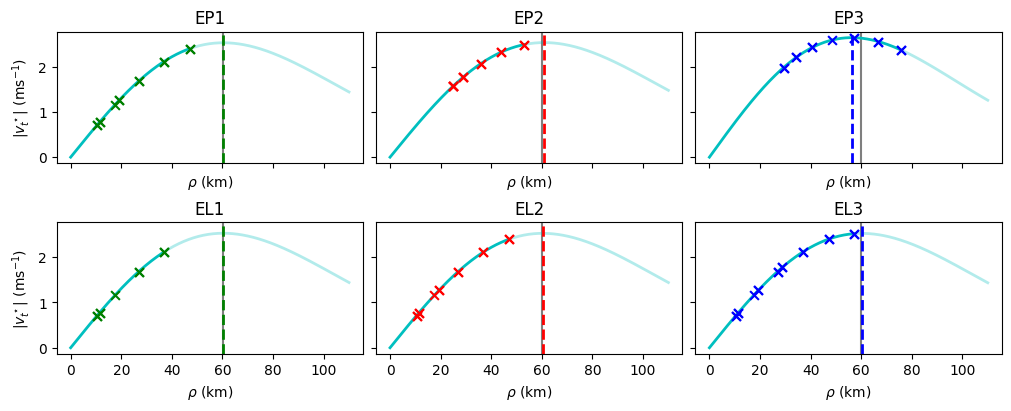

In [6]:
df_res = pd.DataFrame({'xc': [xc], 'yc': [yc], 'w': [w], 'q11': [q11], 'q12': [q12], 'q22': [q22],
                        'Rc': [Rc], 'psi0': [psi0], 'Omega': [Omega]})

nic, njc = 52, 52
r = 6

df_tests = pd.DataFrame({
    'nic': [nic, 45, 44, nic, nic, nic],
    'njc': [njc, 55, 44, njc, njc, njc],
    'r': [r, r, r, r-2, r, r+2]
}, index=['P1', 'P2', 'P3', 'L1', 'L2', 'L3'])

df_tests = df_tests*5

fig, axs = plt.subplots(2, 3, constrained_layout=True, figsize=(10, 4), sharey=True, sharex=True)
axs = axs.flatten()

dic_tests = {}
skip = 10
clrs = ['g', 'r', 'b']*2
for t, test in enumerate(df_tests.index):
    data = df_tests.loc[test]

    x1 = x[data.nic-data.r:data.nic+data.r+1:skip]
    y1 = np.array([y[data.njc]] * len(x1))

    u1 = u[data.nic-data.r:data.nic+data.r+1:skip, data.njc]
    v1 = v[data.nic-data.r:data.nic+data.r+1:skip, data.njc]

    y2 = y[data.njc-data.r:data.njc+data.r+1:skip]
    x2 = np.array([x[data.nic]] * len(y2))

    u2 = u[data.nic, data.njc-data.r:data.njc+data.r+1:skip]
    v2 = v[data.nic, data.njc-data.r:data.njc+data.r+1:skip]

    points1 = set(zip(x1, y1)); points2 = set(zip(x2, y2))
    common_points = points1 & points2
    # Remove duplicates from (x1, y1, u1, v1)
    mask = ~np.array([(x, y) in common_points for x, y in zip(x1, y1)])
    x1f = x1[mask]; y1f = y1[mask]; u1f = u1[mask]; v1f = v1[mask]
    # Concatenate with unaltered second set
    xi = np.concatenate([x1f, x2]); yi = np.concatenate([y1f, y2])
    ui = np.concatenate([u1f, u2]); vi = np.concatenate([v1f, v2])

    xc_dop, yc_dop, w_dop, Q_dop, Omega_dop = doppio(x1, y1, u1, v1, x2, y2, u2, v2)#, plot=True)#, plot=False,
                                                                     # use_A0=True, use_B0=True, use_C0=True, use_D0=True, use_D1=True)

    # xc_dop, yc_dop, w_dop, Q_dop, Omega_dop, df = doppio(x1, y1, u1, v1, x2, y2, u2, v2)
    # print(df)
                                                                    
    # print(param_finder(x1, y1, u1, v1, x2, y2, u2, v2, plot=True))

    df = psi_params(xc_dop, yc_dop, Q_dop, xi, yi, ui, vi)
    Rc_dop, psi0_dop, Omega_dop = out_core_param_fit(df.rho2, df.Qr, df.vt, Omega0=Omega_dop, 
                                     Rc_max=1e6, clr=clrs[t], ax=axs[t], plot=True)
    
    w_dop *= 1e-3
    Omega_dop *= 1e-3
    
    # dic_tests[test] = {'x1': x1, 'y1': y1, 'u1': u1, 'v1': v1,
    #                    'x2': x2, 'y2': y2, 'u2': u2, 'v2': v2,
    #                    'name': test}#, 'U1': U1, 'V1': V1, 'U2': U2, 'V2': V2}
    dic_tests[test] = {'x1': x1, 'y1': y1, 'u1': u1, 'v1': v1,
                       'x2': x2, 'y2': y2, 'u2': u2, 'v2': v2,
                       'name': test, 'U1': [np.nan]*len(x1), 'V1': [np.nan]*len(x1),
                       'U2': [np.nan]*len(y2), 'V2': [np.nan]*len(y2)}

    
    df_res.loc[len(df_res)] = {'xc': xc_dop, 'yc': yc_dop, 'w': w_dop,
                               'q11': Q_dop[0,0], 'q12': Q_dop[0,1], 'q22': Q_dop[1,1],
                               'Rc': Rc_dop, 'psi0': psi0_dop, 'Omega': Omega_dop}

for a, ax in enumerate(axs):
    # if a%2==0:
    ax.set_title('E'+df_tests.index[a])
    ax.set_xlabel(r'$\rho$ (km)')
    if a in [0, 3]:
        ax.set_ylabel(r'$|v_t^\star|$ (ms$^{-1}$)')
    else:
        ax.set_ylabel('')
    ax.axvline(Rc/np.sqrt(2), color='k', zorder=-1, alpha=.5)

df_res.index = ['Control'] + list(df_tests.index)
df_res


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


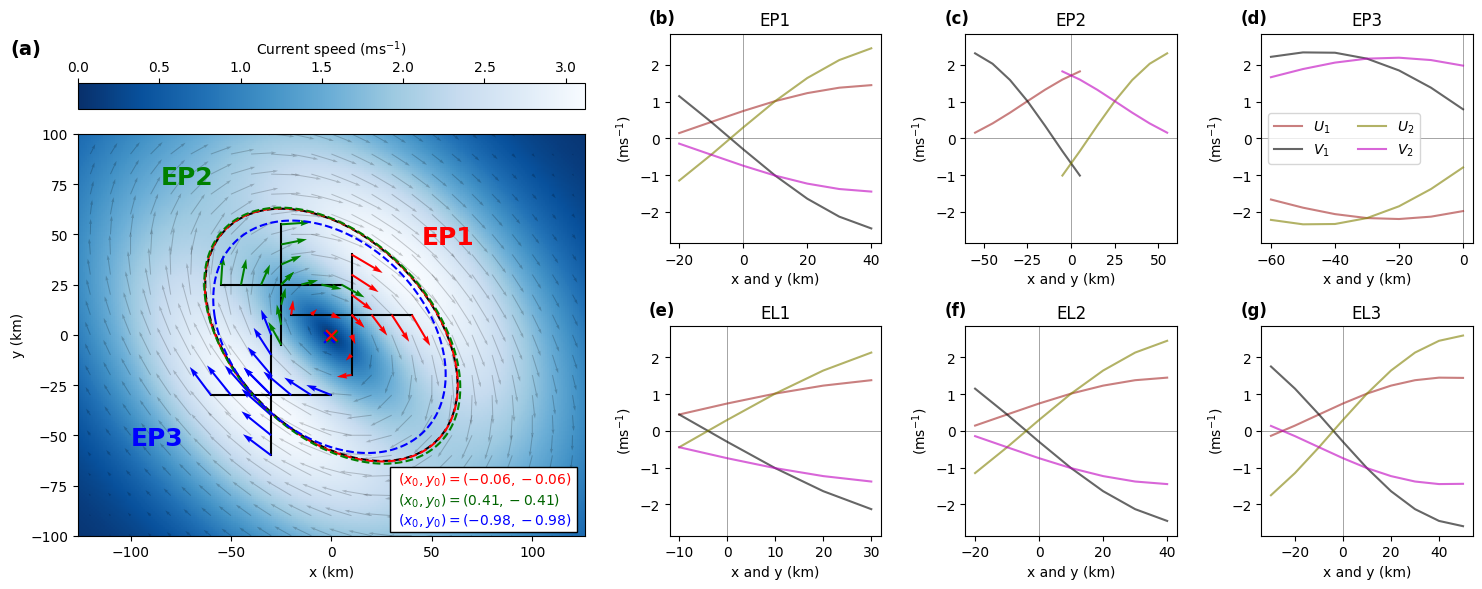

In [7]:
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle

fig = plt.figure(figsize=(15, 6))
gs = gridspec.GridSpec(2, 5, figure=fig)

# Main panel takes first two columns
ax_main = fig.add_subplot(gs[:, :2])

cmap = 'Blues_r'
spacing, scale, width = 10, 40, 0.002

pc = ax_main.pcolor(x, y, np.hypot(u, v).T, cmap=cmap)
plt.colorbar(
    pc, ax=ax_main, orientation='horizontal',
    location='top', label='Current speed (ms$^{-1}$)'
)

ax_main.quiver(
    x[::spacing], y[::spacing],
    u[::spacing, ::spacing].T, v[::spacing, ::spacing].T,
    alpha=0.2, scale=scale, width=width
)

ax_main.contour(X, Y, rho2, levels=[Rc**2/2], colors='k', linestyles='--')

colours = ['r', 'g', 'b']
color = ['r', 'g', 'b']

i = 0
for dic in dic_tests.values():
    if 'P' in dic['name']:
        x1, y1, u1, v1, x2, y2, u2, v2 = (dic[k] for k in ['x1', 'y1', 'u1', 'v1', 'x2', 'y2', 'u2', 'v2'])
        data = df_res.loc[dic['name']]

        ax_main.plot(x1, y1, 'k', zorder=1)
        ax_main.plot(x2, y2, 'k', zorder=1)

        ax_main.quiver(x1, y1, u1, v1, scale=scale, width=width*2, color=colours[i])
        ax_main.quiver(x2, y2, u2, v2, scale=scale, width=width*2, color=colours[i])
        ax_main.scatter(
            data.xc, data.yc, marker='x', s=60, color=colours[i],
            zorder=10-extract_number(dic['name'])
        )

        dx_ell, dy_ell = X - data.xc, Y - data.yc
        rho2_ell = data.q11*dx_ell**2 + 2*data.q12*dx_ell*dy_ell + data.q22*dy_ell**2
        ax_main.contour(
            X, Y, rho2_ell, levels=[data.Rc**2/2],
            colors=colours[i], linestyles='--'
        )

        ax_main.text(
            33, -74 - 10*i,
            fr'$(x_0,y_0)=({data.xc:.2f},{data.yc:.2f})$',
            color='darkgreen' if '2' in dic['name'] else colours[i],
            zorder=11
        )
        i += 1

x_pos, y_pos = 0.80, 0.09
box_width = 0.37
box_height = 0.16
rect = Rectangle(
    (x_pos - box_width / 2, y_pos - box_height / 2),
    box_width, box_height,
    transform=ax_main.transAxes,
    facecolor='white', edgecolor='black', zorder=10
)
ax_main.add_patch(rect)

ax_main.text(-160, 140, '(a)', fontsize=14, fontweight='bold')
ax_main.axis('equal')
ax_main.set_xlim(-100, 100)
ax_main.set_ylim(-100, 100)
ax_main.set_xlabel('x (km)')
ax_main.set_ylabel('y (km)')

axs = []
tags = ['(b)','(c)', '(d)', '(e)', '(f)','(g)']

for d, dic in enumerate(dic_tests.values()):
    x1, y1, u1, v1, x2, y2, u2, v2 = (dic[k] for k in ['x1', 'y1', 'u1', 'v1', 'x2', 'y2', 'u2', 'v2'])
    U1, V1, U2, V2 = (dic[k] for k in ['U1', 'V1', 'U2', 'V2'])
    data = df_res.loc[dic['name']]

    # Put small panels in cols 2, 3, 4
    ax2 = fig.add_subplot(gs[d // 3, 2 + (d % 3)])

    ax2.plot(x1, u1, color='brown', label=r'$U_1$', alpha=.6)
    ax2.plot(x1, U1, color='brown', alpha=.2, marker='*')
    ax2.plot(x1, v1, 'k', label=r'$V_1$', alpha=.6)
    ax2.plot(x1, V1, 'k', alpha=.2, marker='*')
    ax2.plot(y2, u2, color='olive', label=r'$U_2$', alpha=.6)
    ax2.plot(y2, U2, color='olive', alpha=.2, marker='*')
    ax2.plot(y2, v2, 'm', label=r'$V_2$', alpha=.6)
    ax2.plot(y2, V2, 'm', alpha=.2, marker='*')

    ax2.axhline(y=0, color='k', zorder=-1, linewidth=.5, alpha=.5)
    ax2.axvline(x=0, color='k', zorder=-1, linewidth=.5, alpha=.5)
    ax2.set_ylabel('(ms$^{-1}$)')
    ax2.set_xlabel('x and y (km)')
    ax2.set_title('E' + dic['name'])

    if dic['name']=='P3':
        ax2.legend(loc='center left', ncol=2)

    axs.append(ax2)

    ax2.text(-0.1, 1.05, tags[d], fontsize=12, fontweight='bold', transform=ax2.transAxes)

ymin = min(ax.get_ylim()[0] for ax in axs)
ymax = max(ax.get_ylim()[1] for ax in axs)
for ax in axs:
    ax.set_ylim(ymin, ymax)

ax_main.text(45, 45, 'EP1', color=color[0], zorder=3, fontsize=18, fontweight='bold')
ax_main.text(-85, 75, 'EP2', color=color[1], zorder=3, fontsize=18, fontweight='bold')
ax_main.text(-100, -55, 'EP3', color=color[2], zorder=3, fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()


In [8]:
df_paper = df_res.copy()
df_paper['alpha'] = [axis_ratio_from_Q(np.array([[q11, q12], [q12, q22]])) for (q11, q12, q22) in zip(df_paper.q11, df_paper.q12, df_paper.q22)]
df_paper = df_paper.drop(columns=['q11', 'q12', 'q22'])
df_paper


,xc,yc,w,Rc,psi0,Omega,alpha
Control,0.000000,0.000000,-0.000151,85.000000,250.000000,-0.000069,1.527525
P1,-0.061756,-0.061756,-0.000148,85.295308,251.422395,-0.000069,1.523463
P2,0.409749,-0.409749,-0.000138,86.154608,254.362883,-0.000069,1.538592
P3,-0.975451,-0.975451,-0.000138,79.542198,244.940945,-0.000077,1.402122
L1,-0.008558,-0.008558,-0.000149,85.279697,251.586604,-0.000069,1.525301
L2,-0.061756,-0.061756,-0.000148,85.295308,251.422395,-0.000069,1.523463
L3,-0.127344,-0.127344,-0.000146,85.177156,250.978021,-0.000069,1.521085


In [9]:
df_err = (df_paper - df_paper.iloc[0]).abs().iloc[1:]
df_err.index = ['EP1 Err', 'EP2 Err', 'EP3 Err',
                'EL1 Err', 'EL2 Err', 'EL3 Err']
df_err


,xc,yc,w,Rc,psi0,Omega,alpha
EP1 Err,0.061756,0.061756,0.000003,0.295308,1.422395,8.734519e-08,0.004063
EP2 Err,0.409749,0.409749,0.000013,1.154608,4.362883,6.668969e-07,0.011067
EP3 Err,0.975451,0.975451,0.000013,5.457802,5.059055,8.223520e-06,0.125403
EL1 Err,0.008558,0.008558,0.000002,0.279697,1.586604,1.687996e-08,0.002224
EL2 Err,0.061756,0.061756,0.000003,0.295308,1.422395,8.734519e-08,0.004063
EL3 Err,0.127344,0.127344,0.000005,0.177156,0.978021,1.796250e-08,0.006440


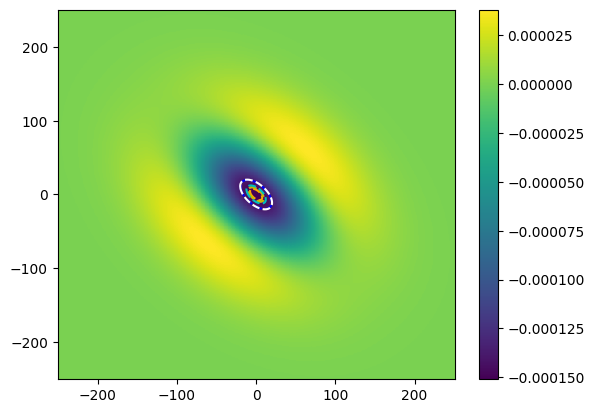

In [10]:
dx = (X[1,0] - X[0,0])*1e3
dy = (Y[0,1] - Y[0,0])*1e3

dv_dx = np.gradient(v, dx, axis=0)
du_dy = np.gradient(u, dy, axis=1)

zeta = dv_dx - du_dy
plt.pcolor(X, Y, zeta)
plt.colorbar()
clrs =['r', 'm', 'b', 'w', 'orange', 'y', 'c']
for i, clr in enumerate(clrs):
    plt.contour(X, Y, zeta, levels=[df_res.iloc[i].w], colors=clr) 
    

In [11]:
# dx = (X[1,0] - X[0,0])*1e3
# dy = (Y[0,1] - Y[0,0])*1e3

# dv_dx = np.gradient(v, dx, axis=0)
# du_dy = np.gradient(u, dy, axis=1)

# zeta = dv_dx - du_dy
# plt.pcolor(X, Y, zeta)
# plt.colorbar()
# plt.contour(X, Y, zeta, levels=[df_res.iloc[0].w], colors='r') 
# # plt.contour(X, Y, zeta, levels=[-0.07391396167122072*1e-3], colors='r') 


### Pres Plots

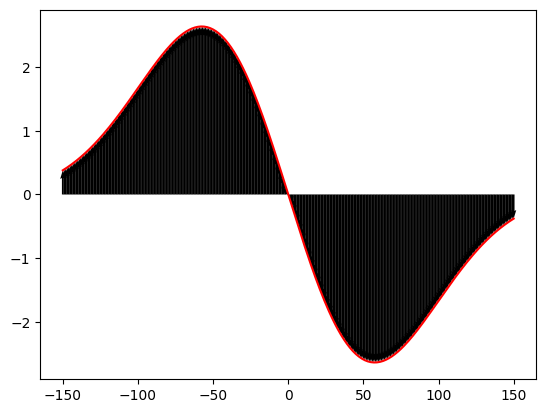

In [12]:
data = pd.DataFrame({'nic': [50], 'njc': [50], 'r': [30]}).iloc[0]*5

x1 = x[data.nic-data.r:data.nic+data.r+1]
y1 = np.array([y[data.njc]] * len(x1))

u1 = u[data.nic-data.r:data.nic+data.r+1, data.njc]
v1 = v[data.nic-data.r:data.nic+data.r+1, data.njc]


plt.quiver(x1, [0]*len(x1), [0]*len(v1), v1, scale_units='xy', scale=1)
plt.plot(x1, v1, color='r') 



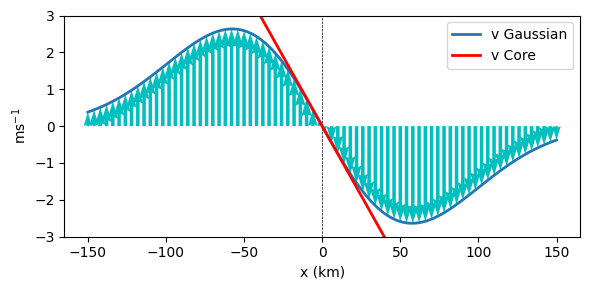

In [13]:
plt.figure(figsize=(6,3))
plt.axvline(x=0, color='k', linewidth=.5, linestyle='--')
plt.plot(x1, v1, linewidth=2, label='v Gaussian')
spac = 4
plt.quiver(x1[::spac], [0]*len(x1[::spac]), [0]*len(v1[::spac]), v1[::spac], scale_units='xy', scale=1, color='c')

vcore = 2*A*q11*(x1-xc) + 2*A*q12*(y1-yc)
plt.plot(x1, vcore, 'r-', linewidth=2, label='v Core')

plt.legend()
plt.xlabel(r'x (km)')
plt.ylabel(r'ms$^{-1}$')
plt.ylim(-3, 3)
plt.tight_layout()


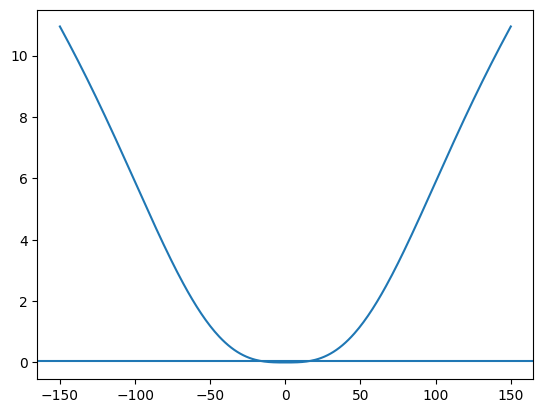

In [14]:
plt.plot(x1, np.abs(vcore-v1))
plt.axhline(y=.05)


In [15]:
def deform_eddy(Q11=1, Q12=0, Q22=1):
    width=500
    x = np.linspace(-width // 2, width // 2, 501)
    y = np.linspace(-width // 2, width // 2, 501)
    X, Y = np.meshgrid(x, y, indexing='ij')
    
    xc, yc = 0.0, 0.0

    psi0 = 250
    Rc = 85.0
    A = - psi0 / Rc**2 
    
    # rescale Q to have unit determinant
    Q, _ = unit_det(Q=np.array([[Q11, Q12], [Q12, Q22]]))
    q11, q12, q22 = Q[0,0], Q[0,1], Q[1,1]
    
    dx, dy = X - xc, Y - yc
    rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2
    Qr2 = (q11*dx + q12*dy)**2 + (q12*dx + q22*dy)**2 # ||Qr||
    psi = psi0 * np.exp( - rho2 / Rc**2 )
    u =   psi0 * np.exp( - rho2 / Rc**2 ) * ( 2*q12*dx + 2*q22*dy ) / Rc**2
    v = - psi0 * np.exp( - rho2 / Rc**2 ) * ( 2*q11*dx + 2*q12*dy ) / Rc**2

    nic, njc, r = 260, 260, 30
    skip = 10
    x1 = x[nic-r:nic+r+1:skip]
    y1 = np.array([y[njc]] * len(x1))

    u1 = u[nic-r:nic+r+1:skip, njc]
    v1 = v[nic-r:nic+r+1:skip, njc]

    y2 = y[njc-r:njc+r+1:skip]
    x2 = np.array([x[nic]] * len(y2))

    u2 = u[nic, njc-r:njc+r+1:skip]
    v2 = v[nic, njc-r:njc+r+1:skip]

    xc_dop, yc_dop, w_dop, Q_dop, Rc_dop, psi0_dop, A_dop = dopioe(x1, y1, u1, v1, x2, y2, u2, v2, plot_flag=False)
    w_dop *= 1e-6
    
    return xc_dop, yc_dop, w_dop, Q_dop, Rc_dop, psi0_dop, A_dop, q11, q12, q22


df_deform_tests = pd.DataFrame({'xc': [xc], 'yc': [yc], 'w': [2*A*(q11+q22)*1e-3], 'q11': [q11], 'q12': [q12], 'q22': [q22],
                        'Rc': [Rc], 'psi0': [psi0], 'A': [A], 'Q11': np.nan, 'Q12': np.nan, 'Q22': np.nan})

for Q12 in np.arange(0.0, .8 + 0.05, 0.05):
    xc_dop, yc_dop, w_dop, Q_dop, Rc_dop, psi0_dop, A_dop, Q11, Q12, Q22 = deform_eddy(Q12=Q12)
    df_deform_tests.loc[len(df_deform_tests)] = {'xc': xc_dop, 'yc': yc_dop, 'w': w_dop, 'q11': Q_dop[0,0], 'q12': Q_dop[1,0], 'q22': Q_dop[1,1],
                        'Rc': Rc_dop, 'psi0': psi0_dop, 'A': A_dop, 'Q11': Q11, 'Q12': Q12, 'Q22': Q22}
df_deform_tests = df_deform_tests.iloc[1:]
df_deform_tests




NameError: name 'dopioe' is not defined

In [ ]:
df_deform_tests['Err'] = np.hypot(df_deform_tests.xc, df_deform_tests.yc)
# Aspect Ratio
ARs = []
for k in range(len(df_deform_tests)):
    data = df_deform_tests.iloc[k]
    ARs.append(ellipse_aspect_ratio(data.Q11, data.Q12, data.Q22))
df_deform_tests['AR'] = ARs
df_deform_tests


In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10,4))

N = len(df_deform_tests)
cmap = plt.cm.cool
cols = cmap(np.linspace(0, 1, N))

# ------------------ RIGHT panel (was left) ------------------
axs[1].plot(df_deform_tests.AR, df_deform_tests.Err, lw=.5, color='k', alpha=.5)
for i, (ar, err) in enumerate(zip(df_deform_tests.AR, df_deform_tests.Err)):
    axs[1].plot(ar, err, marker='x', color=cols[i])

axs[1].set_xlabel('Aspect ratio')
axs[1].set_ylabel('Error (km)')

# ------------------ Grid ------------------
width = 500
x = np.linspace(-width // 2, width // 2, 501)
y = np.linspace(-width // 2, width // 2, 501)
X, Y = np.meshgrid(x, y, indexing='ij')

# ------------------ LEFT panel (was right) ------------------
for i, (q11, q12, q22) in enumerate(zip(df_deform_tests.Q11,
                                      df_deform_tests.Q12,
                                      df_deform_tests.Q22)):
    rho2_ = q11*X**2 + 2*q12*X*Y + q22*Y**2

    axs[0].contour(
        X, Y, rho2_,
        levels=[Rc**2/2],
        colors=[cols[i]],
        linewidths=1.5
    )

for i, (xc_, yc_) in enumerate(zip(df_deform_tests.xc, df_deform_tests.yc)):
    axs[0].plot(xc_, yc_, marker='x', color=cols[i])

# reference transect
nic_, njc_, r_ = 260, 260, 30
skip = 10
x1 = x[nic_-r_:nic_+r_+1:skip]
y1 = np.array([y[njc_]] * len(x1))
y2 = y[njc_-r_:njc_+r_+1:skip]
x2 = np.array([x[nic_]] * len(y2))
axs[0].plot(x1, y1, color='g', lw=2)
axs[0].plot(x2, y2, color='g', lw=2)

axs[0].axis('equal')
axs[0].set_xlim(-100, 100)
axs[0].set_ylim(-100, 100)
axs[0].set_xlabel('x (km)'); axs[0].set_ylabel('y (km)')

plt.tight_layout()


In [ ]:
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle

fig, ax_main = plt.subplots(figsize=(6, 6))

cmap = 'Blues_r'
spacing, scale, width = 2*5, 40, 0.002 #0.004
pc = ax_main.pcolor(x, y, np.hypot(u, v).T, cmap=cmap)
plt.colorbar(pc, ax=ax_main, orientation='horizontal', location='top', label='Current speed [ms$^{-1}$]')
ax_main.quiver(x[::spacing], y[::spacing], u[::spacing, ::spacing].T, v[::spacing, ::spacing].T, 
               alpha=0.2, scale=scale, width=width)

# ax_main.contour(X, Y, rho2, levels=[Rc**2/2],
#                      colors='k', linestyles='--')

colours = ['m', 'g', 'b'] # limegreen
color = ['m', 'g', 'b']

i = 0
scales = [40, 58, 65]
for dic in dic_tests.values():
    if dic['name'] == 'P1':

        x1, y1, u1, v1, x2, y2, u2, v2 = (dic[k] for k in ['x1', 'y1', 'u1', 'v1', 'x2', 'y2', 'u2', 'v2'])
        data = df_res.loc[dic['name']]
 
        ax_main.plot(x1, y1, 'k', zorder=1)
        ax_main.plot(x2, y2, 'k', zorder=1)

        ax_main.quiver(x1, y1, u1, v1, scale=scale, width=width*2, color=colours[i])
        ax_main.quiver(x2, y2, u2, v2, scale=scale, width=width*2, color=colours[i])
        ax_main.scatter(data.xc, data.yc, marker='x', s=60, color=colours[i], zorder=10-extract_number(dic['name']))

        dx_ell, dy_ell = X - data.xc, Y - data.yc
        rho2_ell = data.q11*dx_ell**2 + 2*data.q12*dx_ell*dy_ell + data.q22*dy_ell**2
        ax_main.contour(X, Y, rho2_ell, levels=[data.Rc**2/2], colors=colours[i])

        i += 1

ax_main.axis('equal')
ax_main.set_xlim(-80, 80)
ax_main.set_ylim(-80, 80)
ax_main.set_xlabel('x (km)')
ax_main.set_ylabel('y (km)')

plt.tight_layout()
plt.show()


#### LATTE

In [ ]:
df_tests

In [ ]:
df_latte_res = df_res.copy()
df_latte_res['Method'] = 'doppio'

for t, test in enumerate(df_tests.index):
    data = df_tests.loc[test]

    x1 = x[data.nic-data.r:data.nic+data.r+1:skip]
    y1 = np.array([y[data.njc]] * len(x1))

    u1 = u[data.nic-data.r:data.nic+data.r+1:skip, data.njc]
    v1 = v[data.nic-data.r:data.nic+data.r+1:skip, data.njc]

    y2 = y[data.njc-data.r:data.njc+data.r+1:skip]
    x2 = np.array([x[data.nic]] * len(y2))

    u2 = u[data.nic, data.njc-data.r:data.njc+data.r+1:skip]
    v2 = v[data.nic, data.njc-data.r:data.njc+data.r+1:skip]

    points1 = set(zip(x1, y1)); points2 = set(zip(x2, y2))
    common_points = points1 & points2
    # Remove duplicates from (x1, y1, u1, v1)
    mask = ~np.array([(x, y) in common_points for x, y in zip(x1, y1)])
    x1f = x1[mask]; y1f = y1[mask]; u1f = u1[mask]; v1f = v1[mask]
    # Concatenate with unaltered second set
    xi = np.concatenate([x1f, x2]); yi = np.concatenate([y1f, y2])
    ui = np.concatenate([u1f, u2]); vi = np.concatenate([v1f, v2])

    xc_lat, yc_lat, w_lat, Q_lat, Rc_lat, psi0_lat, A_lat = espra(xi, yi, ui, vi, plot_flag=False)
    w_lat *= 1e-3
    A_lat *= 1e-3
    
    df = psi_params(xc_dop, yc_dop, Q_dop, xi, yi, ui, vi)
    
    df_latte_res.loc[len(df_latte_res)] = {'xc': xc_lat, 'yc': yc_lat, 'w': w_lat,
                               'q11': Q_lat[0,0], 'q12': Q_lat[0,1], 'q22': Q_lat[1,1],
                               'Rc': Rc_lat, 'psi0': psi0_lat, 'Omega': 2*A_lat, 'Method': 'latte'}
df_latte_res.index = list(df_latte_res.index[:7]) + ['P1', 'P2', 'P3', 'L1', 'L2', 'L3']

df_latte_res['alpha'] = [axis_ratio_from_Q(np.array([[q11, q12], [q12, q22]])) for (q11, q12, q22) in zip(df_latte_res.q11, df_latte_res.q12, df_latte_res.q22)]
df_latte_res = df_latte_res.drop(columns=['q11', 'q12', 'q22'])


df_latte_res


In [ ]:
vars_ = ["xc","yc","w","Rc","psi0","alpha","Omega"]

# split methods
df_dop = df_latte_res[df_latte_res.Method=="doppio"]
df_lat = df_latte_res[df_latte_res.Method=="latte"]

# control values (same for both)
ctrl = df_dop.loc["Control", vars_]

rows = []

for test in df_lat.index:
    
    if test == "Control":
        continue
    
    eps = (
        np.abs(df_lat.loc[test, vars_] - ctrl) -
        np.abs(df_dop.loc[test, vars_] - ctrl)
    ) / np.abs(df_lat.loc[test, vars_] - ctrl) * 100
    
    rows.append(eps)

df_pct = pd.DataFrame(rows, index=df_lat.index, columns=vars_)
df_pct
